In [58]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, make_scorer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.inspection import permutation_importance
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Data Load

In [2]:
df_sample = pd.read_csv("sample_submission.csv")
df_test = pd.read_csv("test.csv")
df_train = pd.read_csv("train.csv")
print(f"Train data shape: {df_train.shape}, Test data shape: {df_test.shape}, Sample submission data shape: {df_sample.shape}")
df_train.head()

Train data shape: (439140, 16), Test data shape: (188165, 15), Sample submission data shape: (188165, 2)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [3]:
df_test.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


# Data Description

* id: record id
* Driver: Driver code
* Compound: Tire compound
* Race: Grand Prix name
* Year: Season of the race
* PitStop:  Whether the driver pitted on that lap (0/1)
* LapNumber: Lap index within the race
* Stint: Tire stint number
* TyreLife: Number of laps on current tire
* Position: Driver’s position on that lap
* LapTime (s): Lap time in seconds
* LapTime_Delta: Change in lap time from previous lap
* Cumulative_Degradation: Accumulated tire performance drop
* RaceProgress: Fraction of race completed (0 → 1)
* Position_Change: Position gain/loss compared to previous lap
* PitNextLap: Target variable: whether the driver will pit next lap (0/1)

# EDA

In [4]:
nacount_train = df_train.isna().sum()
nacount_test = df_test.isna().sum()
print(f"Train NA counts: {nacount_train[nacount_train > 0]}, Test NA counts: {nacount_test[nacount_test > 0]}")


Train NA counts: Series([], dtype: int64), Test NA counts: Series([], dtype: int64)


In [5]:
df_train.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


**Observations:**
- There seems to be no missing values
- There is clear outlier in Laptime (s), LapTime_Delta, Cumulative_Degradation
- There is probable outlier in TyreLife and Position change

In [6]:
df_test.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
count,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000
mean,533222.000000,2023.528440,0.136263,23.050185,1.784237,14.160625,9.604539,90.986869,-3.577802,-25.849491,0.336695,0.106800
std,54318.701038,1.025376,0.343069,17.002292,0.948800,9.852778,5.273444,20.855248,40.348466,54.920269,0.253396,4.020592
min,439140.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.017000,-2403.216000,-274.564000,0.012821,-18.000000
25%,486181.000000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.634000,-8.874000,-46.814000,0.128205,-1.000000
50%,533222.000000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.485000,-0.285000,-21.027000,0.269231,0.000000
75%,580263.000000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.485000,0.122000,-6.188000,0.512821,2.000000
max,627304.000000,2025.000000,1.000000,77.000000,8.000000,77.000000,20.000000,2497.905000,2433.472000,2406.800000,1.000000,18.000000


In [7]:
print(f" Train data- Drivers: {df_train['Driver'].nunique()}, Compounds: {df_train['Compound'].nunique()}, Race: {df_train['Race'].nunique()}")
print(f" Test data- Drivers: {df_test['Driver'].nunique()}, Compounds: {df_test['Compound'].nunique()}, Race: {df_test['Race'].nunique()}")

 Train data- Drivers: 887, Compounds: 5, Race: 26
 Test data- Drivers: 801, Compounds: 5, Race: 26


In [8]:
# Analyze the distribution of tire compounds
df_temp = (
    df_train['Compound']
    .value_counts()
    .reset_index()
)
df_temp['Percentage'] = df_temp['count'] / df_temp['count'].sum() * 100
df_temp.head(10)

,Compound,count,Percentage
0,MEDIUM,211141,48.080567
1,HARD,170518,38.829986
2,SOFT,38744,8.822699
3,INTERMEDIATE,17382,3.958191
4,WET,1355,0.308558


In [10]:
# Analyze the distribution of lap times
df_train['LapTime (s)'].describe(), df_train['LapTime (s)'].quantile([ 0.9, 0.99])

(count    439140.000000
 mean         90.948735
 std          19.772769
 min          67.694000
 25%          82.621000
 50%          90.521000
 75%          98.471000
 max        2507.607000
 Name: LapTime (s), dtype: float64,
 0.90    103.69
 0.99    124.90
 Name: LapTime (s), dtype: float64)

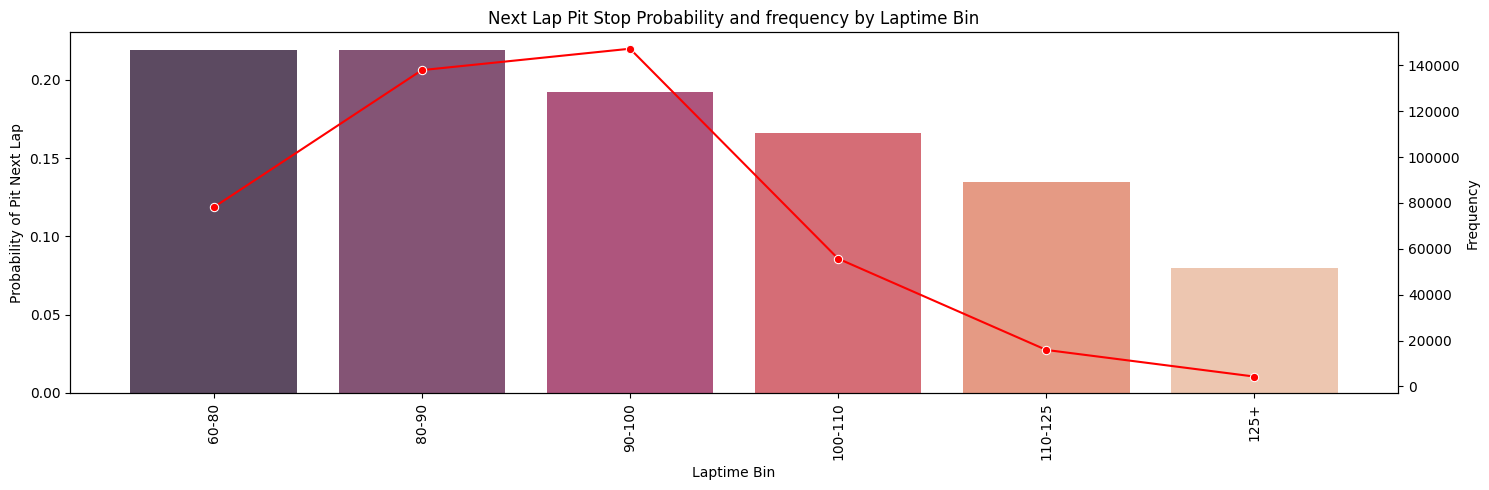

In [11]:
# Fixing the outliers in LapTime (s) by capping at 200 seconds
laptime_bins = [60, 80, 90, 100, 110, 125,  np.inf]
laptime_labels=['60-80', '80-90', '90-100', '100-110', '110-125', '125+']
df_train['Laptime_bin'] = pd.cut(
    df_train['LapTime (s)'], 
    bins=laptime_bins, 
    labels=laptime_labels
)

df_laptime = df_train.groupby('Laptime_bin').agg({'id': 'count', 'PitNextLap': 'mean'}).reset_index()

fig, ax1 = plt.subplots(figsize=(15, 5))
sns.barplot(data=df_laptime, x='Laptime_bin', y='PitNextLap', ax=ax1, palette='rocket', alpha=0.8)
ax1.set_title('Next Lap Pit Stop Probability and frequency by Laptime Bin')
ax1.set_xlabel('Laptime Bin')
ax1.tick_params(axis='x', rotation=90)
ax1.set_ylabel('Probability of Pit Next Lap')

ax2 = ax1.twinx()
sns.lineplot(data=df_laptime, x='Laptime_bin', y='id', color='red', marker='o', ax=ax2)
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Observations:**
- The probability of pitting on the next lap decreases as lap time increases, suggesting drivers are more likely to pit immediately after recording relatively fast laps rather than very slow laps.

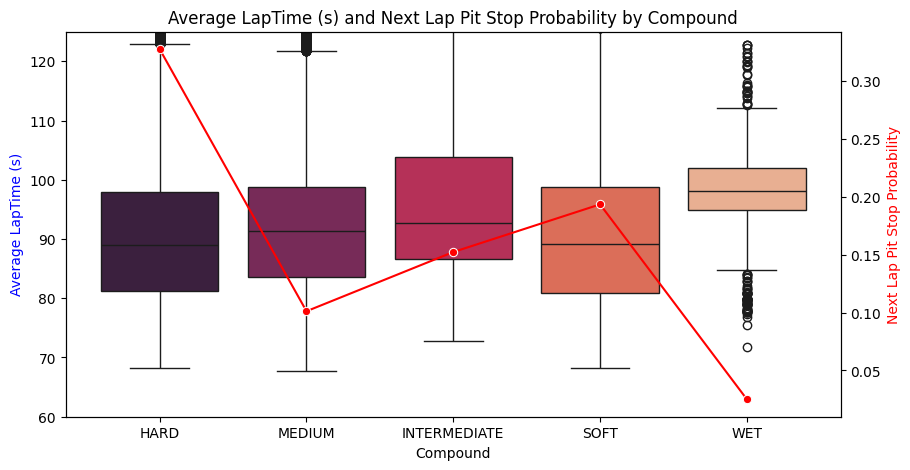

In [13]:
df_comp = (df_train.groupby('Compound').agg({
    'LapTime (s)': 'median', 'PitStop': 'mean', 'PitNextLap': 'mean', 'TyreLife': 'mean', 'LapTime_Delta': 'median', 'Cumulative_Degradation': 'median'
}).reset_index())
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_train, x='Compound', y='LapTime (s)', ax=ax1, palette='rocket')
ax1.set_ylim(60, 125)
ax1.set_ylabel('Average LapTime (s)', color='blue')

ax2 = ax1.twinx()
sns.lineplot(data=df_comp, x='Compound', y='PitNextLap', ax=ax2, color='red', marker='o')
ax2.set_ylabel('Next Lap Pit Stop Probability', color='red')
plt.title('Average LapTime (s) and Next Lap Pit Stop Probability by Compound')
plt.show()

**Observations:**
- Hard tires produces lowest laptime and highest next-lap pit stop probability whereas wet tires produces higher laptime and lowest pit stop probability compartively

In [14]:
# Analyze the distribution of lap time delta
df_train['LapTime_Delta'].describe(), df_train['LapTime_Delta'].quantile([0.01,0.1, 0.9, 0.99])

(count    439140.000000
 mean         -3.770040
 std          43.945759
 min       -2403.895000
 25%          -8.884000
 50%          -0.295000
 75%           0.115000
 max        2423.932000
 Name: LapTime_Delta, dtype: float64,
 0.01   -40.25688
 0.10   -17.43300
 0.90     9.73000
 0.99    30.93200
 Name: LapTime_Delta, dtype: float64)

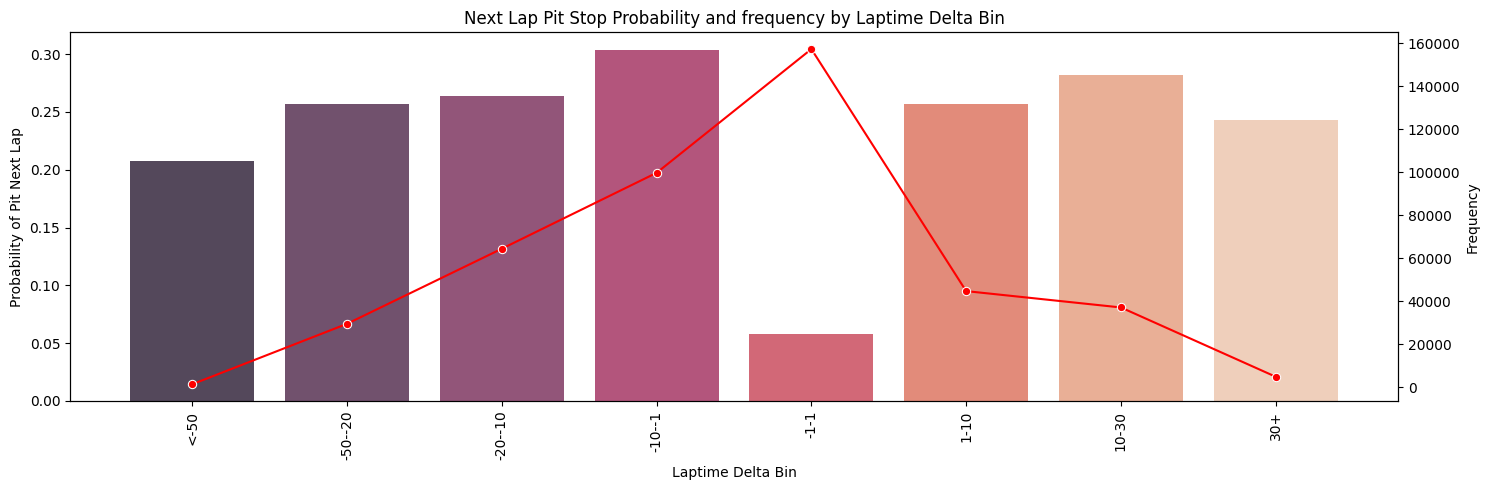

In [15]:
LapTime_Delta_bins = [-np.inf,-50, -20, -10,-1, 1, 10, 30, np.inf]
LapTime_Delta_labels = ['<-50', '-50--20', '-20--10', '-10--1', '-1-1', '1-10', '10-30', '30+']
df_train['LapTime_Delta_bin'] = pd.cut(
    df_train['LapTime_Delta'], 
    bins=LapTime_Delta_bins, 
    labels=LapTime_Delta_labels
)

df_lap_del_bin = df_train.groupby('LapTime_Delta_bin').agg({'id': 'count', 'PitNextLap': 'mean'}).reset_index()

fig, ax1 = plt.subplots(figsize=(15, 5))
sns.barplot(data=df_lap_del_bin, x='LapTime_Delta_bin', y='PitNextLap', ax=ax1, palette='rocket', alpha=0.8)
ax1.set_title('Next Lap Pit Stop Probability and frequency by Laptime Delta Bin')
ax1.set_xlabel('Laptime Delta Bin')
ax1.tick_params(axis='x', rotation=90)
ax1.set_ylabel('Probability of Pit Next Lap')

ax2 = ax1.twinx()
sns.lineplot(data=df_lap_del_bin, x='LapTime_Delta_bin', y='id', color='red', marker='o', ax=ax2)
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [16]:
# Analyze the distribution of lap time delta
df_train['Cumulative_Degradation'].describe(), df_train['Cumulative_Degradation'].quantile([0.01, 0.1, 0.8 ,0.9, 0.99])

(count    439140.000000
 mean        -25.721759
 std          54.766573
 min        -274.564000
 25%         -46.566250
 50%         -20.994000
 75%          -6.199000
 max        2412.026000
 Name: Cumulative_Degradation, dtype: float64,
 0.01   -205.034
 0.10    -75.748
 0.80     -3.900
 0.90     10.491
 0.99    122.154
 Name: Cumulative_Degradation, dtype: float64)

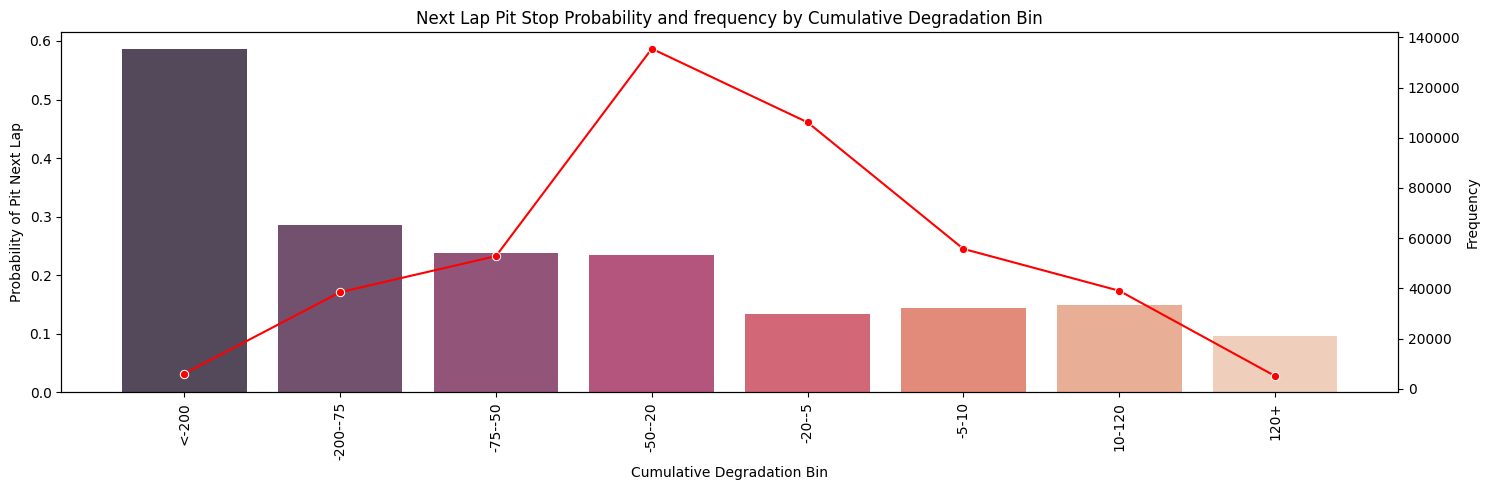

In [17]:
Cumulative_Degradation_bins = [-np.inf, -200, -75, -50,-20, -5, 10, 120, np.inf]
Cumulative_Degradation_labels = ['<-200', '-200--75', '-75--50', '-50--20', '-20--5', '-5-10', '10-120', '120+']
df_train['Cumulative_Degradation_bin'] = pd.cut(
    df_train['Cumulative_Degradation'], 
    bins=Cumulative_Degradation_bins, 
    labels=Cumulative_Degradation_labels
)

df_cum_deg_bin = df_train.groupby('Cumulative_Degradation_bin').agg({'id': 'count', 'PitNextLap': 'mean'}).reset_index()

fig, ax1 = plt.subplots(figsize=(15, 5))
sns.barplot(data=df_cum_deg_bin, x='Cumulative_Degradation_bin', y='PitNextLap', ax=ax1, palette='rocket', alpha=0.8)
ax1.set_title('Next Lap Pit Stop Probability and frequency by Cumulative Degradation Bin')
ax1.set_xlabel('Cumulative Degradation Bin')
ax1.tick_params(axis='x', rotation=90)
ax1.set_ylabel('Probability of Pit Next Lap')

ax2 = ax1.twinx()
sns.lineplot(data=df_cum_deg_bin, x='Cumulative_Degradation_bin', y='id', color='red', marker='o', ax=ax2)
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Observations:**
- Pit-stop probability is highest for extremely negative cumulative degradation values (< -200) and generally decreases as cumulative degradation approaches normal ranges.

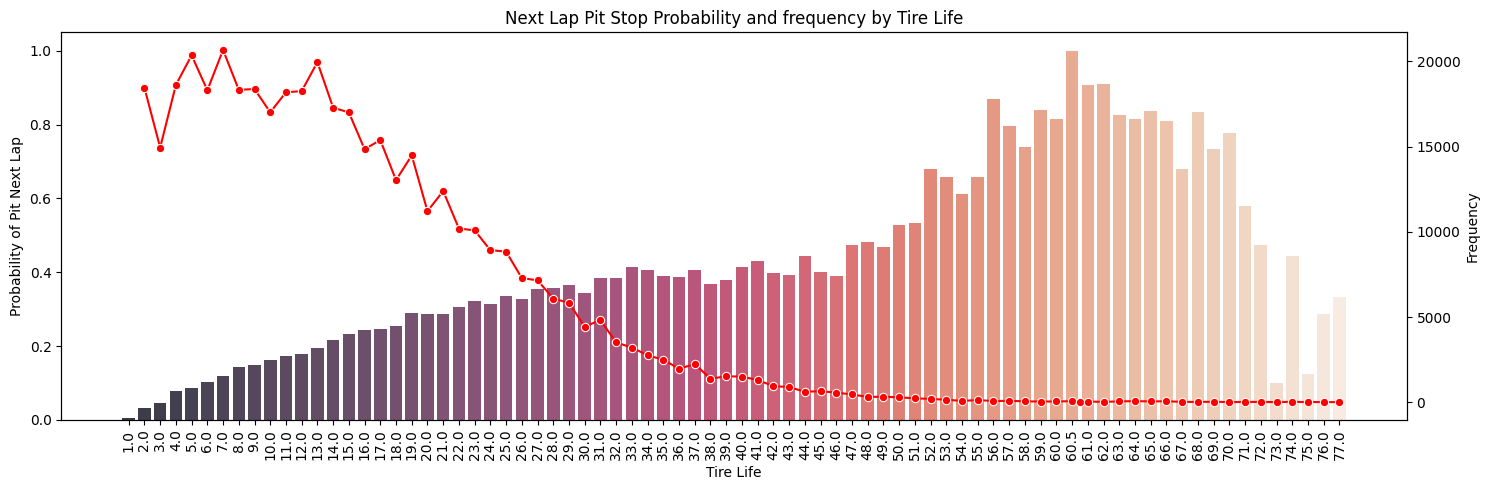

In [18]:
df_tyr = df_train.groupby('TyreLife').agg({'PitNextLap': 'mean','id': 'count'}).reset_index()
fig, ax1 = plt.subplots(figsize=(15, 5))
sns.barplot(data=df_tyr, x='TyreLife', y='PitNextLap', ax=ax1, palette='rocket', alpha=0.8)
ax1.set_title('Next Lap Pit Stop Probability and frequency by Tire Life')
ax1.set_xlabel('Tire Life')
ax1.tick_params(axis='x', rotation=90)
ax1.set_ylabel('Probability of Pit Next Lap')

ax2 = ax1.twinx()
sns.lineplot(data=df_tyr, x='TyreLife', y='id', color='red', marker='o', ax=ax2)
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Observations:**
- Pit-stop probability increases steadily with tire age, peaking around 55–65 laps, indicating tire life is one of the strongest predictors of an upcoming pit stop.

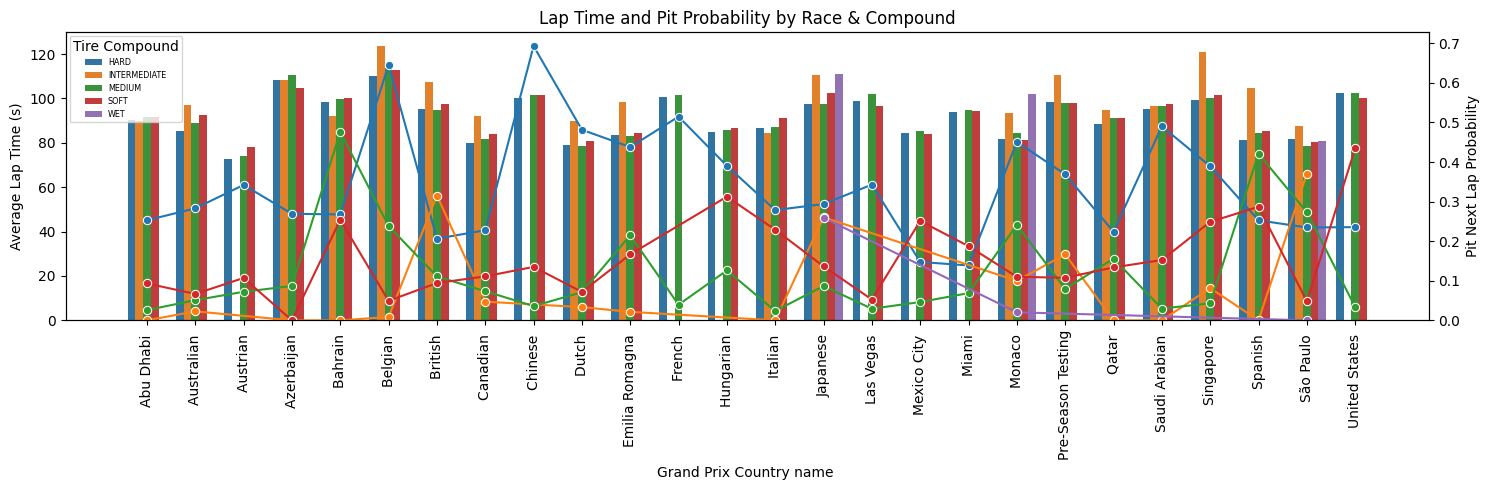

In [19]:
df_comp_rc = df_train.groupby(['Race','Compound'])[['LapTime (s)', 'PitStop', 'PitNextLap']].mean().reset_index()
df_comp_rc['Race_country'] = df_comp_rc['Race'].str.replace('Grand Prix', '', regex=False)

fig, ax1 = plt.subplots(figsize=(15, 5))

sns.barplot(data=df_comp_rc, x='Race_country', y='LapTime (s)', hue='Compound', ax = ax1)
ax1.set_title('Lap Time and Pit Probability by Race & Compound')
ax1.set_ylabel('Average Lap Time (s)')
ax1.set_xlabel("Grand Prix Country name ")
ax1.tick_params(axis='x', rotation=90)

handles1, labels1 = ax1.get_legend_handles_labels()
ax1.legend(handles1, labels1, title='Tire Compound', loc='upper left', fontsize='xx-small',)

ax2 = ax1.twinx()
sns.lineplot(data=df_comp_rc, x='Race_country', y='PitNextLap', ax=ax2, color='red', marker='o', hue='Compound', legend=False)
ax2.set_ylabel('Pit Next Lap Probability')
ax2.set_ylim(0, df_comp_rc['PitNextLap'].max() * 1.05)

plt.tight_layout()
plt.show()

**Observations:**
- Hard and Medium tires are used evrey where, whereas other three component types are missing sometimes
- This chart indicates that laptime is not directly affcet pit stop, eg:
    - Chinese - hard has high pit prob despit lap time being average, 
    - Italian/ Bagrain - intermedate has smallest lap time and also lowest pti stop probability
    - Singapore: High lap times for all compounds, but pit probability varies significantly by compound.

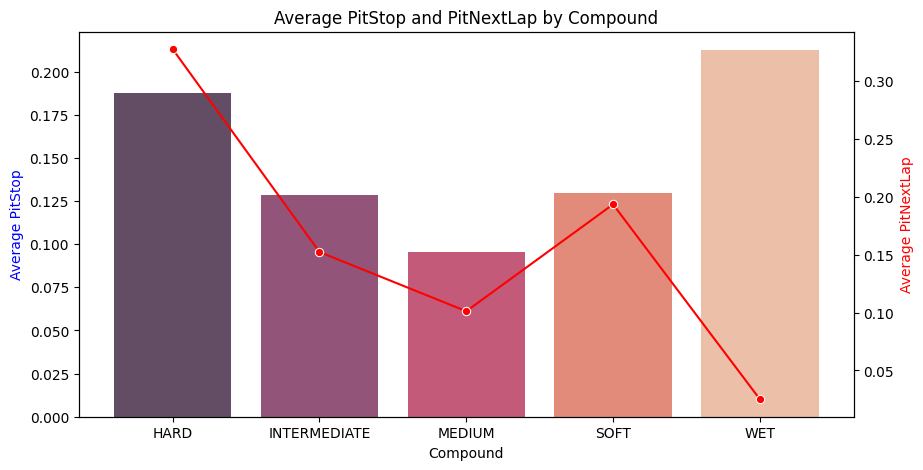

In [20]:

# Analyze the distribution of lap time delta
fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_comp, x='Compound', y='PitStop', ax=ax1, palette='rocket', alpha=0.8)
ax1.set_ylabel('Average PitStop', color='blue')

ax2 = ax1.twinx()
sns.lineplot(data=df_comp, x='Compound', y='PitNextLap', ax=ax2, color='red', marker='o')
ax2.set_ylabel('Average PitNextLap', color='red')
plt.title('Average PitStop and PitNextLap by Compound')
plt.show()

**Observations:**
- Wet tires have the highest overall pit-stop frequency but the lowest next-lap pit probability, indicating their pit stops are driven more by changing track conditions than gradual tire wear.

In [22]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df_train['PitStop'], df_train['PitNextLap']) 
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape)-1)))

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of Freedom: {dof}")
print(f"Cramer's V: {cramers_v:.4f}")
print("\nContingency Table:")
print(contingency_table)



Chi-Square Statistic: 1035.4777
P-value: 0.000000
Degrees of Freedom: 1
Cramer's V: 0.0486

Contingency Table:
PitNextLap     0.0    1.0
PitStop                  
0           306798  72567
1            44961  14814


**Observations**
* P-value < 0.05 means there is PitStop and PitNextLap are not independent
* However, Cramer's V = 0.0486 indicates the association is very weak.

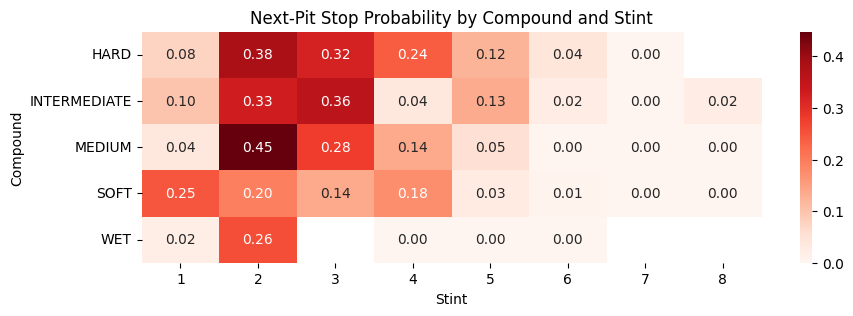

In [23]:
df_pivot = df_train.pivot_table(values='PitNextLap', index='Compound', 
                             columns='Stint', aggfunc='mean')

plt.figure(figsize=(10, 3))
sns.heatmap(df_pivot, annot=True, cmap='Reds', fmt=".2f")
plt.title('Next-Pit Stop Probability by Compound and Stint')
plt.show()

**Observations:**
- Next-pit stop probability peaks during Stint 2 across all compounds and generally decreases in later stints, highlighting stint progression as a key determinant of pit strategy.

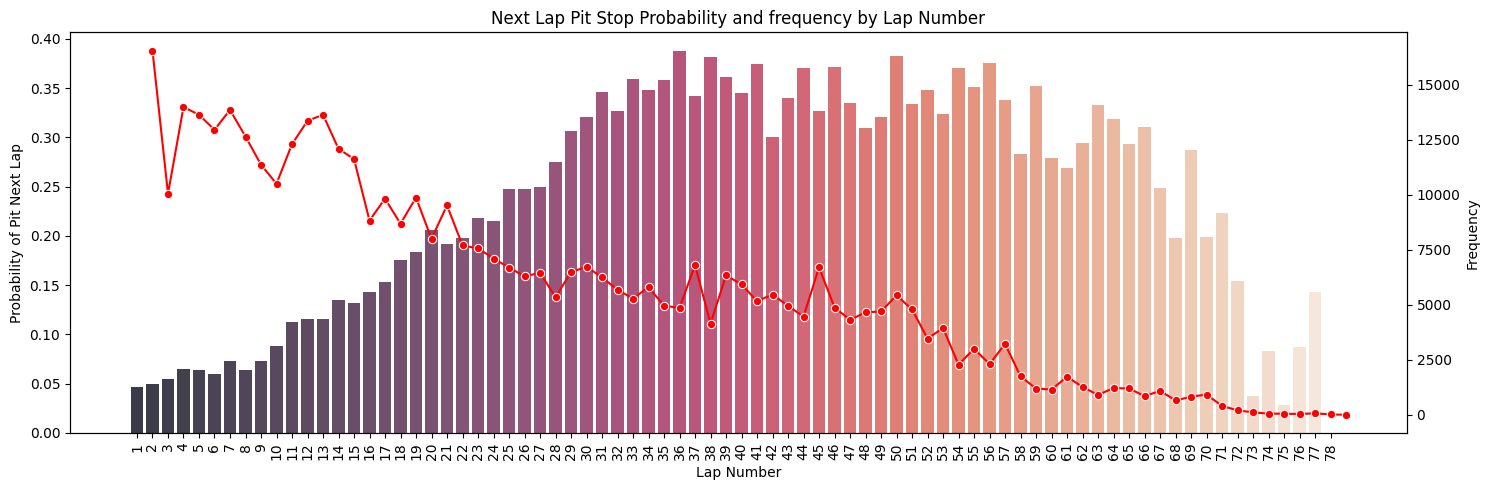

In [24]:
df_lap = df_train.groupby('LapNumber').agg({'PitNextLap': 'mean','id': 'count'}).reset_index()
fig, ax1 = plt.subplots(figsize=(15, 5))
sns.barplot(data=df_lap, x='LapNumber', y='PitNextLap', ax=ax1, palette='rocket', alpha=0.8)
ax1.set_title('Next Lap Pit Stop Probability and frequency by Lap Number')
ax1.set_xlabel('Lap Number')
ax1.tick_params(axis='x', rotation=90)
ax1.set_ylabel('Probability of Pit Next Lap')

ax2 = ax1.twinx()
sns.lineplot(data=df_lap, x='LapNumber', y='id', color='red', marker='o', ax=ax2)
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Observations:**
- Pit-stop probability increases throughout the race, peaks around laps 35–60, and then declines toward the final laps as remaining pit opportunities decrease.
- No need for binning this variable as the anomaly is not that problamatic

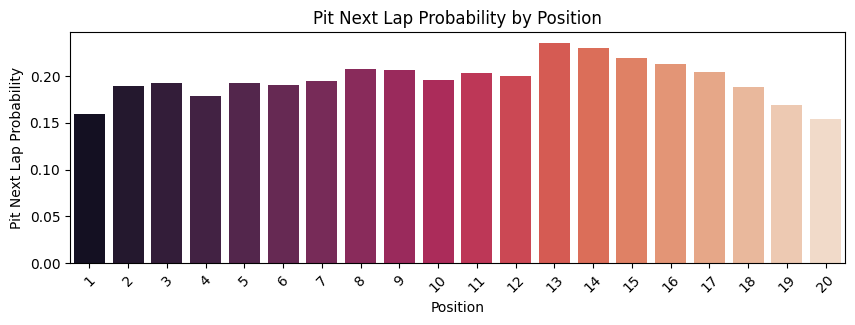

In [314]:

df_pos_bin = df_train.groupby('Position')['PitNextLap'].mean().reset_index()
fig, ax1 = plt.subplots(figsize=(10, 3))
sns.barplot(data=df_pos_bin, x='Position', y='PitNextLap', ax=ax1, palette='rocket')
ax1.set_title('Pit Next Lap Probability by Position')
ax1.set_xlabel('Position')
ax1.set_ylabel('Pit Next Lap Probability')
plt.xticks(rotation=45)
plt.show()

**Observations:**
- Mid-field drivers (positions 13–15) show the highest pit-stop probability, suggesting strategic flexibility is greater in the middle of the field than at the front or rear.

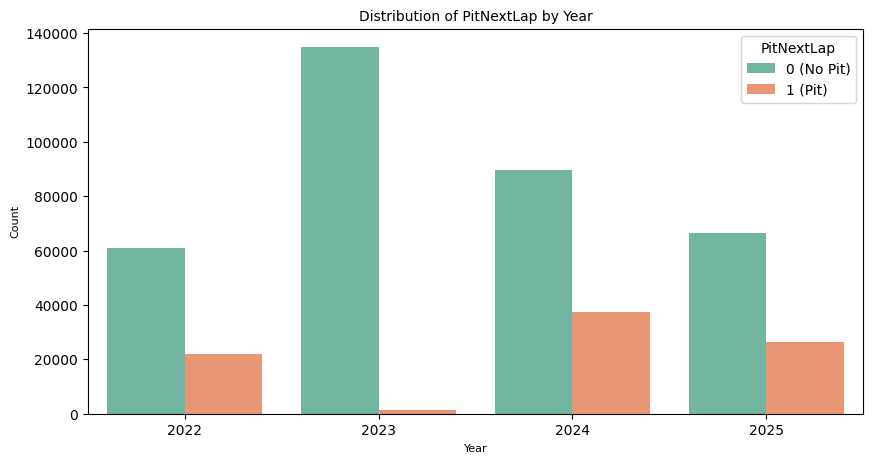

In [315]:
fig, ax = plt.subplots(figsize=(10, 5))
ax = sns.countplot(data=df_train, x='Year', hue='PitNextLap', palette='Set2', ax=ax)

plt.title('Distribution of PitNextLap by Year', fontsize=10)
plt.xlabel('Year', fontsize=8)
plt.ylabel('Count', fontsize=8)

plt.legend(title='PitNextLap', labels=['0 (No Pit)', '1 (Pit)'])
plt.show()

**Observations:**
- The frequency of next-lap pit events varies substantially by season, with 2024 and 2025 exhibiting a much higher proportion of pit events than 2023.

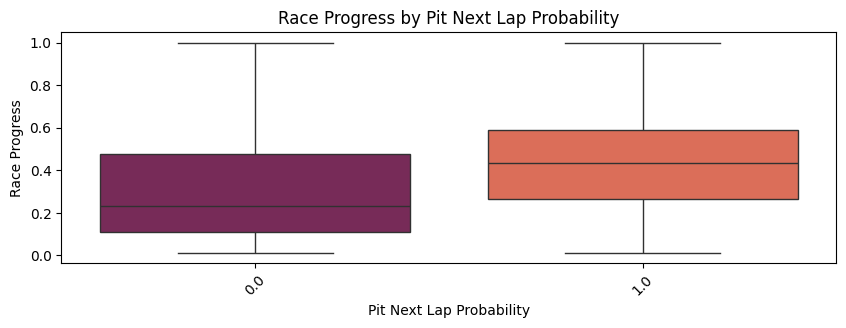

In [317]:
# df_rp = df_train.groupby('RaceProgress')['PitNextLap'].mean().reset_index()
fig, ax1 = plt.subplots(figsize=(10, 3))
sns.boxplot(x='PitNextLap', y='RaceProgress', data=df_train, palette='rocket')
ax1.set_title('Race Progress by Pit Next Lap Probability')
ax1.set_xlabel('Pit Next Lap Probability')
ax1.set_ylabel('Race Progress')
plt.xticks(rotation=45)
plt.show()

## Feature Engineering

In [25]:
# Create new features based on domain knowledge
# Tire Life Utilization: How much of the tire's life has been used up, normalized by the maximum tire life for that compound
df_tire_max = df_train.groupby(['Race', 'Compound'])['TyreLife'].max().reset_index().rename(columns={'TyreLife': 'Tyre_max'})
df_train = df_train.merge(df_tire_max, on=['Race', 'Compound'], how= 'inner')
df_train['TyreLife_Utilization'] = (
    df_train['TyreLife'] /df_train['Tyre_max']    
)

# Degradation Rate: How quickly the lap time is increasing as the tire wears out, calculated as Cumulative_Degradation divided by TyreLife
df_train['Degradation_Rate'] = df_train['Cumulative_Degradation'] / df_train['TyreLife']

df_train['Laptime_bin_num'] = df_train['Laptime_bin'].cat.codes
df_train['LapTime_Delta_bin_num'] = df_train['LapTime_Delta_bin'].cat.codes
df_train['Cumulative_Degradation_bin_num'] = df_train['Cumulative_Degradation_bin'].cat.codes

df_compound = pd.get_dummies(df_train['Compound'], prefix='Comp_', dtype=int).iloc[:, :-1]

df_train = pd.concat([df_train, df_compound], axis=1)
# df_train.head()


In [61]:
df_test = pd.read_csv("test.csv")
print(df_test.shape)
df_test = df_test.merge(df_tire_max, on=['Race', 'Compound'], how= 'left')
df_test['Tyre_max'].fillna(df_test['TyreLife'], inplace=True)
df_test['TyreLife_Utilization'] = (
    df_test['TyreLife'] /df_test['Tyre_max']    
)

df_test['Degradation_Rate'] = df_test['Cumulative_Degradation'] / df_test['TyreLife']

df_test['Laptime_bin'] = pd.cut(df_test['LapTime (s)'], bins=laptime_bins, labels=laptime_labels)
df_test['Laptime_bin_num'] = df_test['Laptime_bin'].cat.codes

df_test['LapTime_Delta_bin'] = pd.cut(df_test['LapTime_Delta'], bins=LapTime_Delta_bins, labels=LapTime_Delta_labels)
df_test['LapTime_Delta_bin_num'] = df_test['LapTime_Delta_bin'].cat.codes

df_test['Cumulative_Degradation_bin'] = pd.cut(df_test['Cumulative_Degradation'], bins=Cumulative_Degradation_bins, labels=Cumulative_Degradation_labels)
df_test['Cumulative_Degradation_bin_num'] = df_test['Cumulative_Degradation_bin'].cat.codes

df_compound = pd.get_dummies(df_test['Compound'], prefix='Comp_', dtype=int).iloc[:, :-1]

df_test = pd.concat([df_test, df_compound], axis=1)
df_test.shape
# df_test.head()

(188165, 15)


(188165, 28)

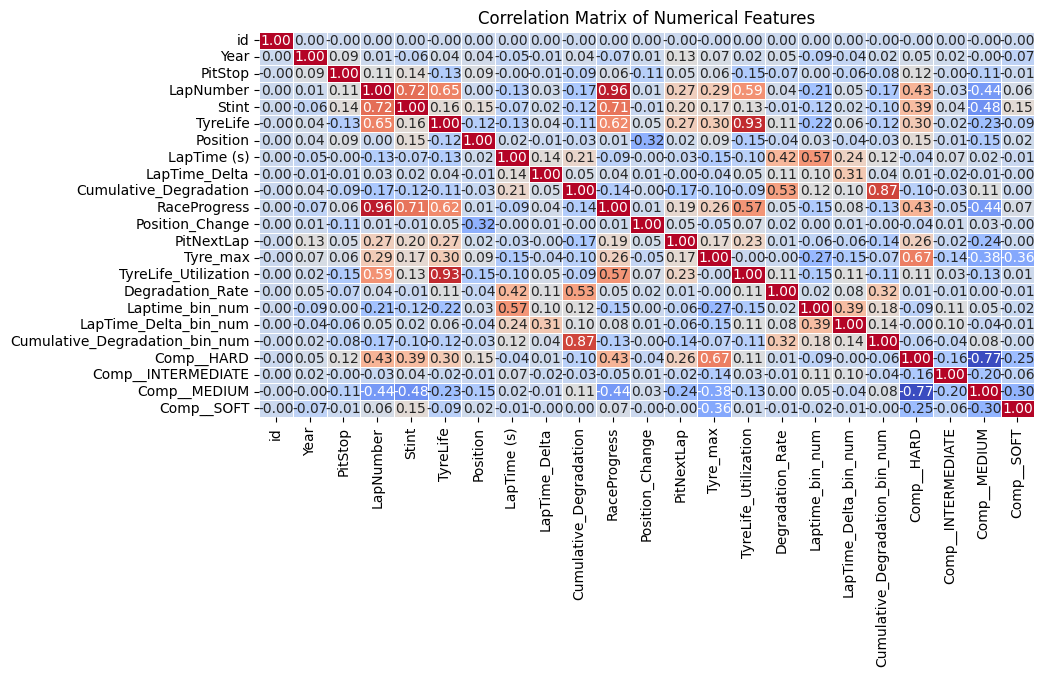

In [27]:

df_train_num = df_train.select_dtypes(include=['int', 'int8', 'float', 'float64'])
df_cr = df_train_num.corr()
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df_cr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar=False, square=False, ax=ax)
plt.title('Correlation Matrix of Numerical Features')
plt.xticks(rotation=90, ha='center')
plt.show()

In [28]:
def optimize_threshold(y_true, y_prob):
    thresholds = np.arange(0, 1.01, 0.01)
    f1_scores = [f1_score(y_true=y_true, y_pred=(y_prob >=t).astype(int)) for t in thresholds]
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    print(f"Best Threshold: {best_threshold:.2f}, F1 Score: {f1_scores[best_idx]:.3f}")
    return best_threshold

In [29]:
def model_info(y_true, y_pred, model_name, model_params, thres, comment):
    conf_mat = confusion_matrix(y_true, y_pred)
    print(classification_report(y_true, y_pred))
    return {
        'Model Name': model_name,
        'Model Parameters': model_params,
        'Probability Threshold': thres,
        'Overall Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall (Sensitivity)': recall_score(y_true, y_pred),
        'f1_score': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_pred),
        'comment': comment
    }


In [30]:
def prepare_train_test(df, feature_list):
    X = df[feature_list]
    y = df['PitNextLap']
    ## Split the data in training and tetsing sets
    X_tr,X_ts,y_tr,y_ts=train_test_split(X,y,test_size=0.3,random_state=42)

    ## Scale these features
    scaler=StandardScaler()
    X_tr=scaler.fit_transform(X_tr)
    X_ts=scaler.transform(X_ts)
    return X_tr, X_ts, y_tr, y_ts, scaler

In [31]:
input_features = [x for x in df_train_num.columns if x not in ['id','PitNextLap', 'LapTime_Delta', 'Cumulative_Degradation', 'LapTime (s)']]
X_train, X_test, y_train, y_test, _ = prepare_train_test(df_train_num, input_features)

mi = mutual_info_classif(X_train, y_train)

model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X_train, y_train)

result = permutation_importance(
    model, X_train, y_train, n_repeats=10, random_state=42
)

df_feature_imp = pd.DataFrame({
    'Feature': input_features,
    'MI': mi,
    'permutation_importance': result.importances_mean,
    'rf_importance': model.feature_importances_
})
df_feature_imp['mi_rank'] = df_feature_imp['MI'].rank(ascending=False)
df_feature_imp['per_rank'] = df_feature_imp['permutation_importance'].rank(ascending=False)
df_feature_imp['rf_rank'] = df_feature_imp['rf_importance'].rank(ascending=False)
df_feature_imp['score'] = df_feature_imp.apply(lambda x: (x['mi_rank'] + x['per_rank'] + x['rf_rank']) /3, axis=1)
df_feature_imp.sort_values('score')

,Feature,MI,permutation_importance,rf_importance,mi_rank,per_rank,rf_rank,score
0,Year,0.081435,0.108018,0.116878,3.0,2.0,1.0,2.000000
3,Stint,0.084662,0.144569,0.089928,2.0,1.0,3.0,2.000000
6,RaceProgress,0.092263,0.053645,0.087977,1.0,5.0,4.0,3.333333
9,TyreLife_Utilization,0.077982,0.064771,0.085631,4.0,4.0,5.0,4.333333
4,TyreLife,0.044576,0.070907,0.078135,10.0,3.0,7.0,6.666667
2,LapNumber,0.046624,0.045757,0.081467,9.0,6.0,6.0,7.000000
10,Degradation_Rate,0.028635,0.041888,0.096857,12.0,7.0,2.0,7.000000
12,LapTime_Delta_bin_num,0.048190,0.040681,0.071081,8.0,8.0,9.0,8.333333
8,Tyre_max,0.052751,0.040659,0.046986,7.0,9.0,11.0,9.000000
7,Position_Change,0.038267,0.035379,0.073858,11.0,10.0,8.0,9.666667


In [65]:
random_state = 42
model_performance_dict = []
input_features = [
    'Stint', 'Year', 'TyreLife_Utilization', 'RaceProgress', 'Degradation_Rate', 'LapTime_Delta_bin_num', 'Position_Change'
]
X_train, X_test, y_train, y_test, scaler = prepare_train_test(df_train, input_features)

In [33]:

param_dist = {
    "n_estimators": np.arange(100, 500, 100),
    "max_depth": [None, 1, 5],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

rf = RandomForestClassifier(random_state=random_state, n_jobs=1)
# Stratified CV for imbalance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring=make_scorer(f1_score),  # optimize for F1
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=random_state
)
search.fit(X_train, y_train)
best_params = search.best_params_
print(f"best params: {best_params}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
best params: {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None, 'bootstrap': True}


In [ ]:
model_rf = RandomForestClassifier(
    **best_params, 
    random_state=random_state, 
    n_jobs=-1, 
    class_weight="balanced_subsample"
)
model_rf.fit(X_train, y_train)
y_trprob = model_rf.predict_proba(X_train)[:,1]
rf_threshold = optimize_threshold(y_train, y_trprob)

y_proba = model_rf.predict_proba(X_test)[:, 1]
y_pred = (y_proba >=rf_threshold).astype(int)
model_performance = model_info(y_test, y_pred, "Random Forest", str(best_params), rf_threshold, input_features)

In [ ]:
# Create features for df_test
X_final = df_test[input_features]
X_final = scaler.transform(X_final)
X_train.shape, X_final.shape

((307398, 8), (188163, 8))

In [ ]:
y_prob_rf = model_rf.predict_proba(X_final)[:, 1]
y_pred_rf = (y_prob_rf >=rf_threshold).astype(int)
df_sample['PitNextLap'] = y_pred_rf
df_sample.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,...,Laptime_bin_num,LapTime_Delta_bin,LapTime_Delta_bin_num,Cumulative_Degradation_bin,Cumulative_Degradation_bin_num,Comp__HARD,Comp__INTERMEDIATE,Comp__MEDIUM,Comp__SOFT,PitNextLap
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,...,2,-1-1,4,-5-10,5,0,0,1,0,0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,...,2,-1-1,4,-5-10,5,0,0,1,0,0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,...,2,-1-1,4,-20--5,4,0,0,1,0,0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,...,2,-20--10,2,-5-10,5,0,0,0,1,0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,...,2,-1-1,4,-50--20,3,1,0,0,0,1


In [ ]:
df_sample.to_csv("my_submission.csv", index=False)